# Dataset preview

Load a small batch with the VAE data configuration and verify its shape, phase range, and appearance.

In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.runtime import build_dataset, build_loader, load_defaults

## Parameters

In [2]:
CONFIG_PATH = ROOT / "config" / "vae.yaml"
BATCH_SIZE = 4
SEED = 20260712

## Load batch

In [3]:
torch.manual_seed(SEED)
args = Namespace(**load_defaults(CONFIG_PATH))
args.data_dir = ROOT / args.data_dir
args.batch_size = BATCH_SIZE

dataset = build_dataset(args)
batch = next(build_loader(dataset, args, device=torch.device("cpu")))

print("dataset:", len(dataset))
print("batch:", tuple(batch.shape))
print("phase range:", (float(batch.min()), float(batch.max())))

dataset: 1
batch: (4, 1, 64, 64)
phase range: (0.0, 2.0)


## Check

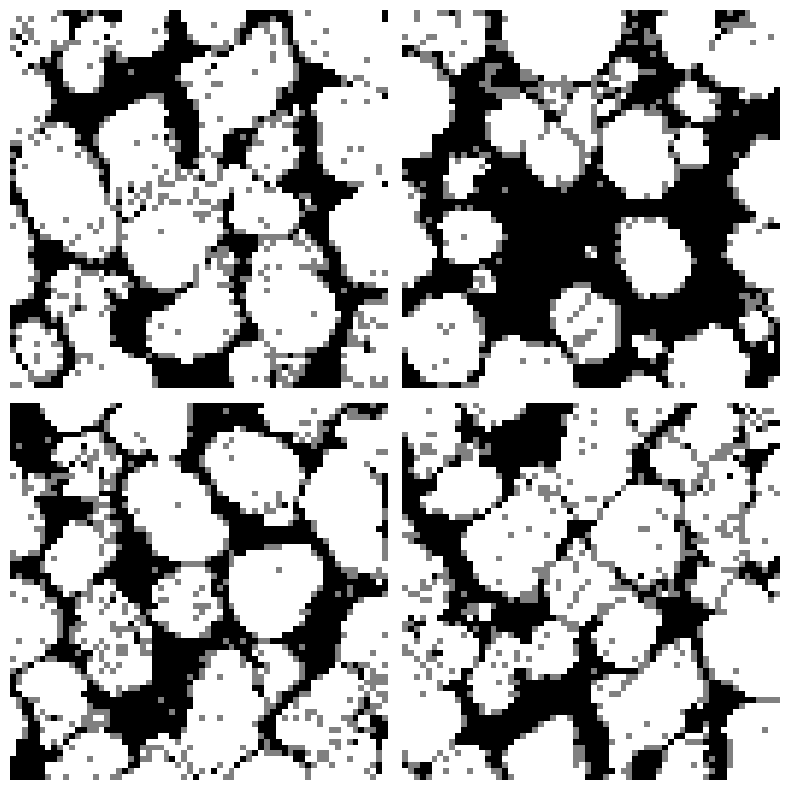

In [4]:
n = min(4, batch.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(8, 8), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, image in zip(axes.ravel(), batch[:n, 0]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=args.num_phases - 1, interpolation="nearest")
plt.tight_layout()